In [ ]:
!pip install ultralytics==8.4.41

In [ ]:
!pip install roboflow -q

from roboflow import Roboflow

rf = Roboflow(api_key="QThjfB4sjPBDi1eJfvsF")
project = rf.workspace("abstract").project("pillsegmentation-oyygy")
version = project.version(1)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import os
import yaml
import glob
from ultralytics import YOLO
from IPython.display import Image, display

dataset_path = dataset.location
yaml_path = os.path.join(dataset_path, "data.yaml")

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

data["train"] = os.path.join(dataset_path, "train/images")
data["val"] = os.path.join(dataset_path, "valid/images")

if os.path.exists(os.path.join(dataset_path, "test/images")):
    data["test"] = os.path.join(dataset_path, "test/images")

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)

print("Dataset:", dataset_path)
print("YAML:", yaml_path)
print("Clases:", data["names"])

Dataset: /content/pillsegmentation-1
YAML: /content/pillsegmentation-1/data.yaml
Clases: ['pill']


In [ ]:
model = YOLO("yolo11m-seg.pt")

results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=640,
    batch=8,
    device=0,
    task="segment",
    project="runs_seg",
    name="pill_seg"
)

New https://pypi.org/project/ultralytics/8.4.80 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pillsegmentation-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

In [ ]:
best_model_path = "/content/runs/segment/runs_seg/pill_seg-4/weights/best.pt"
best_model = YOLO(best_model_path)

metrics = best_model.val(
    data=yaml_path,
    imgsz=640,
    device=0,
    task="segment"
)

print("Box mAP50:", metrics.box.map50)
print("Box mAP50-95:", metrics.box.map)
print("Mask mAP50:", metrics.seg.map50)
print("Mask mAP50-95:", metrics.seg.map)

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m-seg summary (fused): 139 layers, 22,336,083 parameters, 0 gradients, 112.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1473.9±684.4 MB/s, size: 34.2 KB)
val: Scanning /content/pillsegmentation-1/valid/labels.cache... 598 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 598/598 228.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 38/38 1.4it/s 27.9s
                   all        598       3810      0.948      0.963      0.978      0.956       0.95      0.965      0.979      0.909
Speed: 2.0ms preprocess, 36.9ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/segment/val
Box mAP50: 0.9782210686565995
Box mAP50-95: 0.9558614391928831
Mask mAP50: 0.9789391325009996
Mask mAP50-95: 0.9092744991396016


In [ ]:
results_dir = "runs_seg/pill_seg"

plots = [
    "results.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "BoxP_curve.png",
    "BoxR_curve.png",
    "BoxF1_curve.png",
    "BoxPR_curve.png",
    "MaskP_curve.png",
    "MaskR_curve.png",
    "MaskF1_curve.png",
    "MaskPR_curve.png"
]

for plot in plots:
    path = os.path.join(results_dir, plot)
    if os.path.exists(path):
        print(plot)
        display(Image(filename=path))


image 1/1 /content/istockphoto-1224227498-612x612.jpg: 448x640 24 pills, 39.5ms
Speed: 2.7ms preprocess, 39.5ms inference, 2.8ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/segment/predict


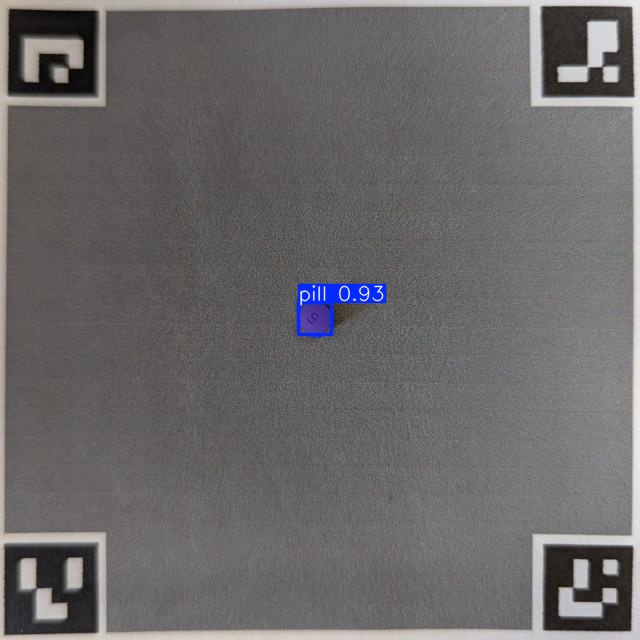

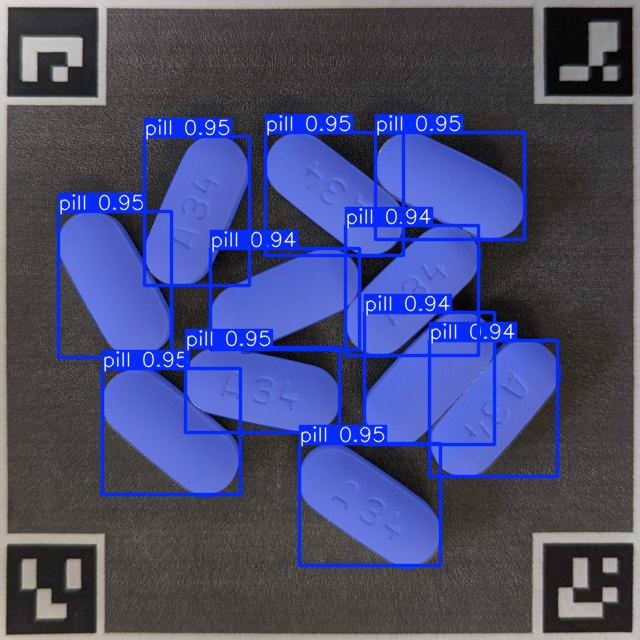

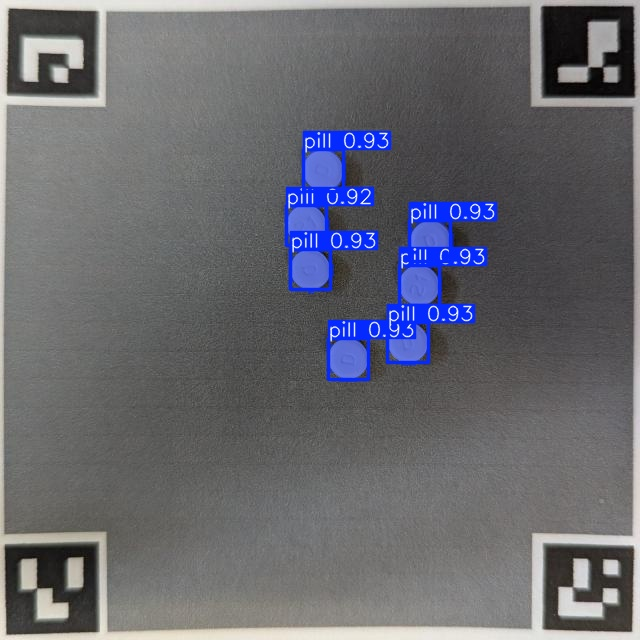

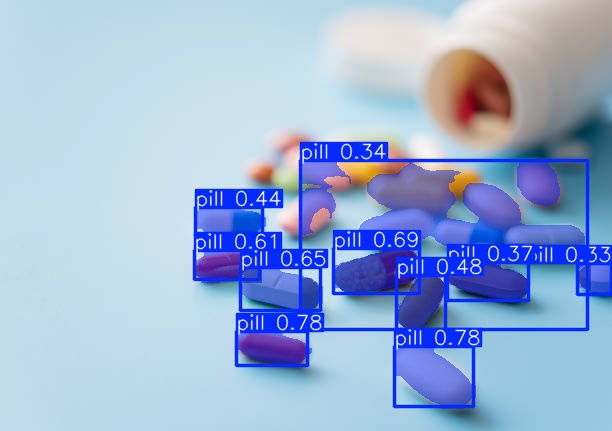

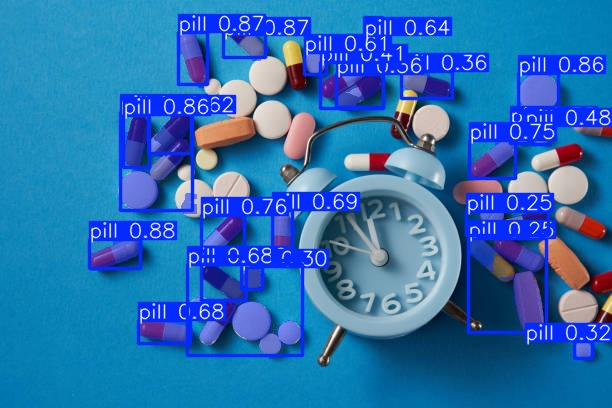

In [ ]:
test_images = glob.glob(os.path.join(dataset_path, "test/images/*"))

if len(test_images) == 0:
    test_images = glob.glob(os.path.join(dataset_path, "valid/images/*"))

best_model.predict(
    source="/content/istockphoto-1224227498-612x612.jpg",
    imgsz=640,
    conf=0.25,
    device=0,
    save=True
)

pred_dirs = sorted(glob.glob("runs/segment/predict*"))
pred_imgs = glob.glob(os.path.join(pred_dirs[-1], "*"))

for img in pred_imgs[:12]:
    display(Image(filename=img))